[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HisameOgasahara/tmp_diffsynth_practive/blob/main/anima_minimal_colab.ipynb)

# Minimal Anima T2I — extracted DiffSynth path

ComfyUI / Diffusers / DiffSynth를 설치하거나 별도 git clone하지 않습니다. 이 저장소의 최소 모델 정의와 일반 Python 라이브러리만 사용합니다. 모델 가중치는 공개 Hugging Face `circlestone-labs/Anima`에서 인증 없이 받습니다.


In [1]:
# 1. Colab 기본 torch / transformers / huggingface_hub / Pillow는 그대로 사용
!pip -q install safetensors einops sentencepiece tqdm


In [2]:
# 2. 이 실습 저장소만 clone / 최신 코드 강제 반영
from pathlib import Path
import importlib, subprocess, sys, torch

REPO = 'https://github.com/HisameOgasahara/tmp_diffsynth_practive.git'
ROOT = Path('/content/tmp_diffsynth_practive')
if not ROOT.exists():
    subprocess.run(['git', 'clone', '--depth', '1', REPO, str(ROOT)], check=True)
else:
    subprocess.run(['git', '-C', str(ROOT), 'fetch', 'origin', 'main'], check=True)
    subprocess.run(['git', '-C', str(ROOT), 'reset', '--hard', 'origin/main'], check=True)

SRC = str(ROOT / 'src')
if SRC not in sys.path:
    sys.path.insert(0, SRC)

if 'anima_core.model_cache' in sys.modules:
    sys.modules['anima_core.model_cache'].clear_model_cache()

for name in list(sys.modules):
    if name == 'anima_core' or name.startswith('anima_core.'):
        del sys.modules[name]
importlib.invalidate_caches()

commit = subprocess.check_output(['git', '-C', str(ROOT), 'rev-parse', '--short', 'HEAD'], text=True).strip()
print('commit:', commit)
print(torch.__version__, torch.cuda.get_device_name() if torch.cuda.is_available() else 'NO CUDA')


commit: 4e2a01f
2.11.0+cu128 Tesla T4


In [21]:
# 3. Baseline 생성값 — 수정 후 JSON으로 저장
import json
from pathlib import Path

PROMPT = '(@ogipote:1.5), (@yoneyama mai:0.7), anime coloring, 1girl, shirakawa yuina, blue headgear, plaitinum blonde hair, upper body, solo, cute, cheerful, innocent, expressionless, looking_at_viewer, alternte costume, black t-shirt, denim, sitting, holding_sketchbook sunlight, soft_lighting, gentle_breeze, floating_particles, futuristic_city, academy_city, glass_building, on rooftop, night, blue_and_white_theme, pastel_colors, vibrant_colors, depth_of_field, wallpaper' # @param {type:'string'}
NEGATIVE_PROMPT = 'worst quality, low quality, score_1, score_2, score_3, blurry, jpeg artifacts' # @param {type:'string'}
SEED = 1113280783077048 # @param {type:'integer'}
RANDOM_SEED = True # @param {type:'boolean'}
STEPS = 30 # @param {type:'integer'}
CFG = 4.0 # @param {type:'number'}
WIDTH = 1216 # @param {type:'integer'}
HEIGHT = 832 # @param {type:'integer'}
DENOISE = 1.0 # @param {type:'number'}
SHIFT = 3.0 # @param {type:'number'}
USE_TOKEN_WEIGHTS = True # @param {type:'boolean'}
USE_MODEL_CACHE = True # @param {type:'boolean'}
LOG_LEVEL = 'INFO' # @param ['DEBUG', 'INFO', 'WARNING', 'ERROR']
SHOW_PROGRESS = True # @param {type:'boolean'}
ENABLE_PROFILER = False # @param {type:'boolean'}
PROFILE_STAGES = 'sample_euler' # @param {type:'string'}
PROFILE_OUTPUT_DIR = '/content/anima_profiles' # @param {type:'string'}
PROFILE_WAIT = 0 # @param {type:'integer'}
PROFILE_WARMUP = 1 # @param {type:'integer'}
PROFILE_ACTIVE = 3 # @param {type:'integer'}
PROFILE_RECORD_SHAPES = False # @param {type:'boolean'}
PROFILE_MEMORY = False # @param {type:'boolean'}
PROFILE_WITH_STACK = False # @param {type:'boolean'}
PROFILE_ROW_LIMIT = 20 # @param {type:'integer'}

CONFIG_PATH = Path('/content/anima_minimal_config.json')
config = {
    'prompt': PROMPT,
    'negative_prompt': NEGATIVE_PROMPT,
    'seed': int(SEED),
    'random_seed': RANDOM_SEED,
    'steps': int(STEPS),
    'cfg': float(CFG),
    'width': int(WIDTH),
    'height': int(HEIGHT),
    'denoise': float(DENOISE),
    'shift': float(SHIFT),
    'device': 'cuda',
    'dtype': 'float16',
    'lora_path': '',
    'lora_scale': 1.0,
    'use_token_weights': USE_TOKEN_WEIGHTS,
    'use_model_cache': USE_MODEL_CACHE,
    'logging': {'level': LOG_LEVEL, 'progress': SHOW_PROGRESS},
    'profiler': {
        'enabled': ENABLE_PROFILER,
        'stages': [name.strip() for name in PROFILE_STAGES.split(',') if name.strip()],
        'output_dir': PROFILE_OUTPUT_DIR,
        'wait': PROFILE_WAIT, 'warmup': PROFILE_WARMUP, 'active': PROFILE_ACTIVE,
        'record_shapes': PROFILE_RECORD_SHAPES,
        'profile_memory': PROFILE_MEMORY,
        'with_stack': PROFILE_WITH_STACK,
        'row_limit': PROFILE_ROW_LIMIT,
    },
}
CONFIG_PATH.write_text(json.dumps(config, ensure_ascii=False, indent=2), encoding='utf-8')
print(CONFIG_PATH)
print(json.dumps(config, ensure_ascii=False, indent=2))


/content/anima_minimal_config.json
{
  "prompt": "(@ogipote:1.5), (@yoneyama mai:0.7), anime coloring, 1girl, shirakawa yuina, blue headgear, plaitinum blonde hair, upper body, solo, cute, cheerful, innocent, expressionless, looking_at_viewer, alternte costume, black t-shirt, denim, sitting, holding_sketchbook sunlight, soft_lighting, gentle_breeze, floating_particles, futuristic_city, academy_city, glass_building, on rooftop, night, blue_and_white_theme, pastel_colors, vibrant_colors, depth_of_field, wallpaper",
  "negative_prompt": "worst quality, low quality, score_1, score_2, score_3, blurry, jpeg artifacts",
  "seed": 1113280783077048,
  "random_seed": true,
  "steps": 30,
  "cfg": 4.0,
  "width": 1216,
  "height": 832,
  "denoise": 1.0,
  "shift": 3.0,
  "device": "cuda",
  "dtype": "float16",
  "lora_path": "",
  "lora_scale": 1.0,
  "use_token_weights": true,
  "use_model_cache": true,
  "logging": {
    "level": "INFO",
    "progress": true
  },
  "profiler": {
    "enabled": 

In [16]:
# 4. 공개 HF에서 Anima 가중치 미리 받기 — 선택 셀, token/auth 없음
import json
from pathlib import Path
from anima_core.runtime import configure_diagnostics, download_weights
configure_diagnostics(json.loads(Path('/content/anima_minimal_config.json').read_text(encoding='utf-8')))
download_weights()
print('가중치 캐시 준비 완료')


08:07:12 | INFO | 모델 가중치 다운로드/캐시 확인 시작
08:07:12 | INFO | dit 가중치 확인: split_files/diffusion_models/anima-base-v1.0.safetensors
08:07:12 | INFO | dit 가중치 준비 완료
08:07:12 | INFO | text_encoder 가중치 확인: split_files/text_encoders/qwen_3_06b_base.safetensors
08:07:12 | INFO | text_encoder 가중치 준비 완료
08:07:12 | INFO | vae 가중치 확인: split_files/vae/qwen_image_vae.safetensors
08:07:12 | INFO | vae 가중치 준비 완료
08:07:12 | INFO | 모델 가중치 다운로드/캐시 확인 완료 (경과 0.01초)
가중치 캐시 준비 완료


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 선택: Anima LoRA 파일 준비

3번 셀 다음에 실행하세요. 로컬/Google Drive 파일 경로 또는 HF 저장소와 파일명을 입력합니다. `LORA_PATH`가 비어 있으면 기본 T2I로 생성합니다. LoRA 적용은 `src/anima_core/lora.py`에서 처리하며, 6번 셀에서 text adapter 계산 전에 가중치에 합칩니다.

표준 Linear LoRA의 `lora_A/B[.default].weight`와 `lora_down/up.weight`, 레이어별 `alpha`를 지원합니다. 다른 모델용 LoRA, DoRA/LyCORIS, fused QKV 전용 가중치는 지원하지 않습니다. LoRA 설명에 필요한 트리거 단어가 있으면 3번 셀의 prompt에 넣으세요.


In [22]:
# 4-1. 선택: LoRA 다운로드/경로 설정 (적용 로직은 Python 모듈에 있음)
import json
from pathlib import Path

LORA_SOURCE = 'google_drive' # @param ['local', 'google_drive', 'hugging_face']
LORA_PATH = '/content/drive/MyDrive/Anima_results/Anima/loras/anima_lora-step00000400.safetensors' # @param {type:'string'}
LORA_SCALE = 0.8 # @param {type:'number'}
HF_LORA_REPO = '' # @param {type:'string'}
HF_LORA_FILENAME = '' # @param {type:'string'}
HF_LORA_REVISION = 'main' # @param {type:'string'}

if LORA_SOURCE == 'google_drive':
    from google.colab import drive
    drive.mount('/content/drive')
elif LORA_SOURCE == 'hugging_face':
    from huggingface_hub import hf_hub_download
    LORA_PATH = hf_hub_download(repo_id=HF_LORA_REPO, filename=HF_LORA_FILENAME, revision=HF_LORA_REVISION)

CONFIG_PATH = Path('/content/anima_minimal_config.json')
config = json.loads(CONFIG_PATH.read_text(encoding='utf-8'))
config['lora_path'] = LORA_PATH.strip()
config['lora_scale'] = float(LORA_SCALE)
CONFIG_PATH.write_text(json.dumps(config, ensure_ascii=False, indent=2), encoding='utf-8')
print('LoRA:', config['lora_path'] or '사용 안 함', 'scale:', config['lora_scale'])


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
LoRA: /content/drive/MyDrive/Anima_results/Anima/loras/anima_lora-step00000400.safetensors scale: 0.8


In [23]:
# 5. Text Encoder -> positive / negative conditioning 저장
import gc, json, torch
from pathlib import Path
from anima_core.runtime import configure_diagnostics, download_weights, load_tokenizers, encode_prompt
from anima_core.model_cache import use_text_encoder

CONFIG_PATH = Path('/content/anima_minimal_config.json')
if not CONFIG_PATH.exists():
    raise RuntimeError('3번 셀을 먼저 실행해서 생성 설정 JSON을 만들어주세요.')
config = json.loads(CONFIG_PATH.read_text(encoding='utf-8'))
configure_diagnostics(config)
device = config['device']
dtype = getattr(torch, config['dtype'])
weights = download_weights()

qwen_tokenizer, t5_tokenizer = load_tokenizers()
with use_text_encoder(weights['text_encoder'], device, dtype, enabled=config.get('use_model_cache', False)) as text_encoder:
    positive_raw, positive_t5, positive_weights = encode_prompt(text_encoder, qwen_tokenizer, t5_tokenizer, config['prompt'], device, dtype, use_token_weights=config.get('use_token_weights', False), return_token_weights=True)
    negative_raw, negative_t5, negative_weights = encode_prompt(text_encoder, qwen_tokenizer, t5_tokenizer, config['negative_prompt'], device, dtype, use_token_weights=config.get('use_token_weights', False), return_token_weights=True)

CONDITIONING_PATH = Path('/content/anima_conditioning.pt')
torch.save({
    'positive_raw': positive_raw.cpu(),
    'positive_t5': positive_t5.cpu(),
    'positive_weights': positive_weights.cpu(),
    'negative_raw': negative_raw.cpu(),
    'negative_t5': negative_t5.cpu(),
    'negative_weights': negative_weights.cpu(),
}, CONDITIONING_PATH)

del text_encoder, positive_raw, positive_t5, negative_raw, negative_t5, positive_weights, negative_weights
gc.collect(); torch.cuda.empty_cache()
print('conditioning:', CONDITIONING_PATH)


08:09:27 | INFO | 모델 가중치 다운로드/캐시 확인 시작
08:09:27 | INFO | dit 가중치 확인: split_files/diffusion_models/anima-base-v1.0.safetensors
08:09:27 | INFO | dit 가중치 준비 완료
08:09:27 | INFO | text_encoder 가중치 확인: split_files/text_encoders/qwen_3_06b_base.safetensors
08:09:27 | INFO | text_encoder 가중치 준비 완료
08:09:27 | INFO | vae 가중치 확인: split_files/vae/qwen_image_vae.safetensors
08:09:27 | INFO | vae 가중치 준비 완료
08:09:27 | INFO | 모델 가중치 다운로드/캐시 확인 완료 (경과 0.01초)
08:09:27 | INFO | Qwen/T5 tokenizer 로딩 시작
08:09:29 | INFO | Qwen/T5 tokenizer 로딩 완료 (경과 2.56초)
08:09:29 | INFO | text_encoder 캐시 hit: 파일 재로딩 없이 재사용
08:09:29 | INFO | 캐시 모델 장치 이동 시작
08:09:29 | INFO | ZImageTextEncoder -> cuda
08:09:30 | INFO | 캐시 모델 장치 이동 완료 (경과 0.42초)
08:09:30 | INFO | Qwen prompt encoding 시작
08:09:30 | INFO | Qwen prompt encoding 완료 (경과 0.10초)
08:09:30 | INFO | Qwen prompt encoding 시작
08:09:30 | INFO | Qwen prompt encoding 완료 (경과 0.08초)
08:09:30 | INFO | 캐시 모델 장치 이동 시작
08:09:30 | INFO | ZImageTextEncoder -> cpu
08:09:30 | INFO | 

In [24]:
# 6. Anima text adapter + DiT + CFG + Euler -> latent 저장
import gc, json, torch
import secrets
from pathlib import Path
from anima_core.runtime import configure_diagnostics, download_weights, adapt_conditioning, sample_euler
from anima_core.model_cache import use_dit

CONFIG_PATH = Path('/content/anima_minimal_config.json')
CONDITIONING_PATH = Path('/content/anima_conditioning.pt')
if not CONFIG_PATH.exists():
    raise RuntimeError('3번 셀을 먼저 실행해서 생성 설정 JSON을 만들어주세요.')
if not CONDITIONING_PATH.exists():
    raise RuntimeError('5번 셀을 먼저 실행해서 conditioning 파일을 만들어주세요.')

config = json.loads(CONFIG_PATH.read_text(encoding='utf-8'))
configure_diagnostics(config)
device = config['device']
dtype = getattr(torch, config['dtype'])
weights = download_weights()
conditioning = torch.load(CONDITIONING_PATH, map_location='cpu')
seed = secrets.randbelow(torch.iinfo(torch.int64).max) if config.get('random_seed', False) else config['seed']
print('생성 시드:', seed)

with use_dit(
    weights['dit'], device, dtype,
    enabled=config.get('use_model_cache', False),
    lora_path=config.get('lora_path'),
    lora_scale=config.get('lora_scale', 1.0),
) as dit:
    positive = adapt_conditioning(
        dit,
        conditioning['positive_raw'].to(device=device, dtype=dtype),
        conditioning['positive_t5'].to(device),
        t5_weights=conditioning['positive_weights'].to(device=device, dtype=dtype) if 'positive_weights' in conditioning else None,
    )
    negative = adapt_conditioning(
        dit,
        conditioning['negative_raw'].to(device=device, dtype=dtype),
        conditioning['negative_t5'].to(device),
        t5_weights=conditioning['negative_weights'].to(device=device, dtype=dtype) if 'negative_weights' in conditioning else None,
    )

    latents = sample_euler(
        dit,
        positive,
        negative,
        config['height'],
        config['width'],
        seed,
        config['steps'],
        config['cfg'],
        denoise=config['denoise'],
        shift=config['shift'],
        device=device,
        dtype=dtype,
    )

    LATENTS_PATH = Path('/content/anima_latents.pt')
    torch.save(latents.cpu(), LATENTS_PATH)
del dit, positive, negative, latents, conditioning
gc.collect(); torch.cuda.empty_cache()
print('latents:', LATENTS_PATH)


08:09:32 | INFO | 모델 가중치 다운로드/캐시 확인 시작
08:09:32 | INFO | dit 가중치 확인: split_files/diffusion_models/anima-base-v1.0.safetensors
08:09:32 | INFO | dit 가중치 준비 완료
08:09:32 | INFO | text_encoder 가중치 확인: split_files/text_encoders/qwen_3_06b_base.safetensors
08:09:32 | INFO | text_encoder 가중치 준비 완료
08:09:32 | INFO | vae 가중치 확인: split_files/vae/qwen_image_vae.safetensors
08:09:32 | INFO | vae 가중치 준비 완료
08:09:32 | INFO | 모델 가중치 다운로드/캐시 확인 완료 (경과 0.01초)
생성 시드: 8452348319962476595
08:09:32 | INFO | dit 캐시 hit: 파일 재로딩 없이 재사용
08:09:32 | INFO | 캐시 모델 장치 이동 시작
08:09:32 | INFO | AnimaDiT -> cuda
08:09:33 | INFO | 캐시 모델 장치 이동 완료 (경과 1.26초)
08:09:33 | INFO | Anima text adapter conditioning 시작
08:09:33 | INFO | Anima text adapter conditioning 완료 (경과 0.01초)
08:09:33 | INFO | Anima text adapter conditioning 시작
08:09:33 | INFO | Anima text adapter conditioning 완료 (경과 0.01초)
08:09:33 | INFO | Euler 이미지 생성 시작
08:09:33 | INFO | 생성 설정: 1216x832, steps=30, CFG=4.0, seed=8452348319962476595


Euler 생성:   0%|          | 0/30 [00:00<?, ?it/s]

08:10:53 | INFO | Euler 이미지 생성 완료 (경과 79.61초)
08:10:53 | INFO | 캐시 모델 장치 이동 시작
08:10:53 | INFO | AnimaDiT -> cpu
08:10:55 | INFO | 캐시 모델 장치 이동 완료 (경과 1.88초)
08:10:55 | INFO | dit: CPU RAM에 보관
latents: /content/anima_latents.pt


08:10:55 | INFO | 모델 가중치 다운로드/캐시 확인 시작
08:10:55 | INFO | dit 가중치 확인: split_files/diffusion_models/anima-base-v1.0.safetensors
08:10:55 | INFO | dit 가중치 준비 완료
08:10:55 | INFO | text_encoder 가중치 확인: split_files/text_encoders/qwen_3_06b_base.safetensors
08:10:55 | INFO | text_encoder 가중치 준비 완료
08:10:55 | INFO | vae 가중치 확인: split_files/vae/qwen_image_vae.safetensors
08:10:55 | INFO | vae 가중치 준비 완료
08:10:55 | INFO | 모델 가중치 다운로드/캐시 확인 완료 (경과 0.01초)
08:10:55 | INFO | vae 캐시 hit: 파일 재로딩 없이 재사용
08:10:55 | INFO | 캐시 모델 장치 이동 시작
08:10:55 | INFO | WanVideoVAE -> cuda
08:10:55 | INFO | 캐시 모델 장치 이동 완료 (경과 0.08초)
08:10:55 | INFO | VAE 이미지 디코딩 시작
08:10:56 | INFO | VAE 이미지 디코딩 완료 (경과 1.00초)
08:10:56 | INFO | 캐시 모델 장치 이동 시작
08:10:56 | INFO | WanVideoVAE -> cpu
08:10:56 | INFO | 캐시 모델 장치 이동 완료 (경과 0.08초)
08:10:56 | INFO | vae: CPU RAM에 보관


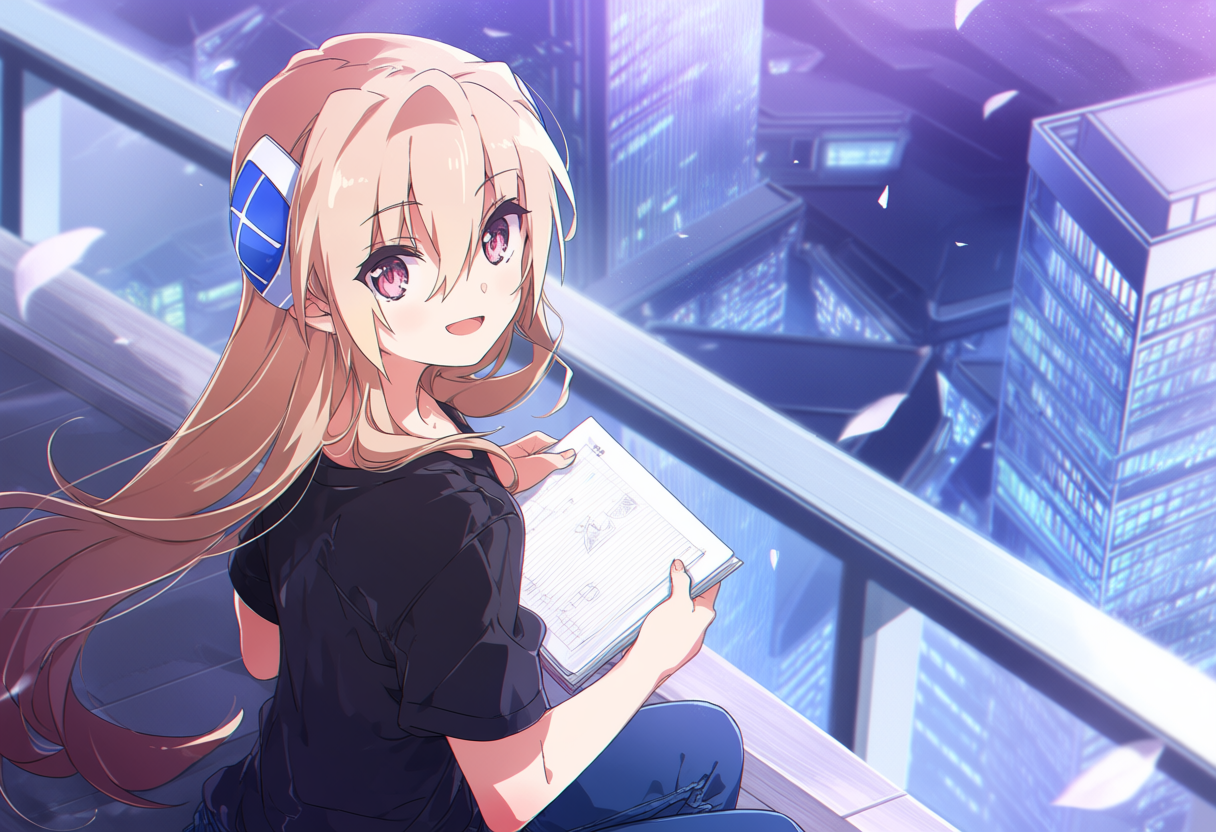

/content/anima_minimal.png


In [25]:
# 7. VAE decode -> PNG
import gc, json, torch
from pathlib import Path
from IPython.display import display
from anima_core.runtime import configure_diagnostics, download_weights, decode_image
from anima_core.model_cache import use_vae

CONFIG_PATH = Path('/content/anima_minimal_config.json')
LATENTS_PATH = Path('/content/anima_latents.pt')
if not CONFIG_PATH.exists():
    raise RuntimeError('3번 셀을 먼저 실행해서 생성 설정 JSON을 만들어주세요.')
if not LATENTS_PATH.exists():
    raise RuntimeError('6번 셀을 먼저 실행해서 latent 파일을 만들어주세요.')

config = json.loads(CONFIG_PATH.read_text(encoding='utf-8'))
configure_diagnostics(config)
device = config['device']
dtype = getattr(torch, config['dtype'])
weights = download_weights()
latents = torch.load(LATENTS_PATH, map_location='cpu').to(device=device, dtype=dtype)

with use_vae(weights['vae'], device, dtype, enabled=config.get('use_model_cache', False)) as vae:
    image = decode_image(vae, latents, device)
OUTPUT = Path('/content/anima_minimal.png')
image.save(OUTPUT)
display(image)
print(OUTPUT)

del vae, latents
gc.collect(); torch.cuda.empty_cache()
